In [ ]:
import pathlib
from tqdm import tqdm

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation



import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from IPython.display import HTML, display
from ipywidgets import IntSlider, FloatSlider, Dropdown, Output, VBox, HBox
from ipywidgets import interact, interactive

In [22]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

file_name = "data"
data_path = pathlib.Path("data")

train_df = pd.read_csv(data_path / f"{file_name}_train.csv")
valid_df = pd.read_csv(data_path / f"{file_name}_valid.csv")
test_df = pd.read_csv(data_path / f"{file_name}_test.csv")

input_col_names = ['time', 're', 'x', 'y']
target_col_names = ['U_x', 'U_y', 'p']

In [63]:
train_df.describe()

,time,re,x,y,U_x,U_y,p
count,24576.000000,24576.000000,24576.000000,24576.000000,24576.000000,24576.000000,24576.000000
mean,0.200000,662.500000,0.044181,0.050000,0.000057,0.012094,-0.020476
std,0.163303,112.502289,0.028747,0.028865,0.167980,0.107028,0.093597
min,0.000000,550.000000,0.000541,0.000781,-0.229171,-0.496671,-3.047410
25%,0.000000,550.000000,0.019156,0.025391,-0.065646,0.000000,-0.043411
50%,0.200000,662.500000,0.041292,0.050000,-0.003512,0.000000,-0.000137
75%,0.400000,775.000000,0.067615,0.074609,0.000000,0.040804,0.000000
max,0.400000,775.000000,0.098918,0.099219,0.953575,0.321847,2.758810


In [64]:
valid_df.describe()

,time,re,x,y,U_x,U_y,p
count,12288.000000,12288.0,12288.000000,12288.000000,12288.000000,12288.000000,12288.000000
mean,0.200000,325.0,0.044181,0.050000,0.000056,0.012970,-0.021149
std,0.163306,0.0,0.028747,0.028865,0.172889,0.111938,0.173038
min,0.000000,325.0,0.000541,0.000781,-0.212282,-0.431154,-5.260850
25%,0.000000,325.0,0.019156,0.025391,-0.072079,-0.000257,-0.032438
50%,0.200000,325.0,0.041292,0.050000,-0.003608,0.000000,0.000000
75%,0.400000,325.0,0.067615,0.074609,0.000000,0.038148,0.000000
max,0.400000,325.0,0.098918,0.099219,0.954056,0.339638,4.362110


In [65]:
test_df.describe()

,time,re,x,y,U_x,U_y,p
count,49152.000000,49152.0,49152.000000,49152.000000,49152.000000,49152.000000,49152.000000
mean,0.200000,1000.0,0.044225,0.050000,0.000017,0.016487,-5.884867
std,0.163301,0.0,0.028751,0.028867,0.271957,0.223322,5.245646
min,0.000000,1000.0,0.000271,0.000391,-0.813456,-1.687220,-22.977000
25%,0.000000,1000.0,0.019038,0.025195,-0.098638,-0.006002,-11.851200
50%,0.200000,1000.0,0.041356,0.050000,0.000000,0.000000,-5.129225
75%,0.400000,1000.0,0.067897,0.074805,0.000000,0.065902,0.000000
max,0.400000,1000.0,0.099459,0.099609,2.789840,2.619710,1.112300


In [66]:
mean = train_df.mean()
std = train_df.std()

train_df = (train_df - mean) / std
valid_df = (valid_df - mean) / std
test_df = (test_df - mean) / std

In [24]:
train_dataset = TensorDataset(torch.tensor(train_df[input_col_names].to_numpy(), dtype=torch.float32), 
              torch.tensor(train_df[target_col_names].to_numpy(), dtype=torch.float32))

valid_dataset = TensorDataset(torch.tensor(valid_df[input_col_names].to_numpy(), dtype=torch.float32), 
              torch.tensor(valid_df[target_col_names].to_numpy(), dtype=torch.float32))

test_dataset = TensorDataset(torch.tensor(test_df[input_col_names].to_numpy(), dtype=torch.float32), 
              torch.tensor(test_df[target_col_names].to_numpy(), dtype=torch.float32))

In [25]:
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=256)
test_dataloader = DataLoader(valid_dataset, batch_size=256)

In [19]:
class PINN(torch.nn.Module):
    def __init__(self, in_size, out_size):
        super().__init__()

        self.fc1 = nn.Linear(in_size, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, out_size)
        
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)

        return x

In [20]:
class NavierStokesLoss(torch.nn.Module):
    def __init__(self, c_physics):
        super().__init__()
        self.c_physics = c_physics

    def forward(self, input, pred, target):
        re = input[:, 1]

        u = pred[:, 0]
        v = pred[:, 1]
        p = pred[:, 2]

        u_x, u_y, u_xx, u_yy, v_x, v_y, v_xx, v_yy, p_x, p_y = self.calc_grads(input, u, v, p)

        # data loss
        loss = nn.MSELoss()(pred, target)

        # physics loss
        f_c = u_x + v_y
        f_u = u * u_x + v * u_y + p_x - 1 / re * (u_xx + u_yy)
        f_v = u * v_x + v * v_y + p_y - 1 / re * (v_xx + v_yy)

        loss += self.c_physics * (torch.mean(f_c ** 2) + torch.mean(f_u ** 2) + torch.mean(f_v ** 2))

        return loss

    def calc_grads(self, input, u, v, p):
        u_grad = torch.autograd.grad(
            u,
            input,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        v_grad = torch.autograd.grad(
            v,
            input,
            grad_outputs=torch.ones_like(v),
            create_graph=True
        )[0]

        p_grad = torch.autograd.grad(
            p,
            input,
            grad_outputs=torch.ones_like(p),
            create_graph=True
        )[0]

        u_x = u_grad[:, 2]
        u_y = u_grad[:, 3]

        v_x = v_grad[:, 2]
        v_y = v_grad[:, 3]

        p_x = p_grad[:, 2]
        p_y = p_grad[:, 3]

        u_xx = torch.autograd.grad(
            u_x,
            input,
            grad_outputs=torch.ones_like(u_x),
            create_graph=True
        )[0][:, 2]

        u_yy = torch.autograd.grad(
            u_y,
            input,
            grad_outputs=torch.ones_like(u_y),
            create_graph=True
        )[0][:, 3]

        v_xx = torch.autograd.grad(
            v_x,
            input,
            grad_outputs=torch.ones_like(v_x),
            create_graph=True
        )[0][:, 2]

        v_yy = torch.autograd.grad(
            v_y,
            input,
            grad_outputs=torch.ones_like(v_y),
            create_graph=True
        )[0][:, 3]

        return u_x, u_y, u_xx, u_yy, v_x, v_y, v_xx, v_yy, p_x, p_y


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [72]:
model = PINN(len(input_col_names), len(target_col_names)).to(device)
criterion = NavierStokesLoss(0.1)
optimizer = torch.optim.Adam(model.parameters())

EPOCHS = 20

In [73]:
train_losses = []
valid_losses = []

In [74]:
for epoch in range(EPOCHS):
    model.train()

    train_loss = 0.0

    for input, target in tqdm(train_dataloader):
        input = input.to(device)
        input.requires_grad_(True)
        target = target.to(device)

        pred = model(input)

        optimizer.zero_grad()
        loss = criterion(input, pred, target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataloader)

    model.eval()
    valid_loss = 0.0

    for input, target in valid_dataloader:
        input = input.to(device)
        input.requires_grad_(True)
        target = target.to(device)

        pred = model(input)
        loss = criterion(input, pred, target)
        valid_loss += loss.item()

    valid_loss /= len(valid_dataloader)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    print(f"Epoch {epoch}: train loss: {train_loss}, valid loss: {valid_loss}")


100%|██████████| 96/96 [00:00<00:00, 116.50it/s]


Epoch 0: train loss: 0.669686603670319, valid loss: 1.5669113810484607


100%|██████████| 96/96 [00:00<00:00, 101.43it/s]


Epoch 1: train loss: 0.5317436419427395, valid loss: 1.714189346258839


100%|██████████| 96/96 [00:00<00:00, 120.32it/s]


...

Epoch 17: train loss: 0.38696609251201153, valid loss: 1.9146905730788906


100%|██████████| 96/96 [00:00<00:00, 118.57it/s]


Epoch 18: train loss: 0.3808615158001582, valid loss: 2.0007120355342827


100%|██████████| 96/96 [00:00<00:00, 116.76it/s]


Epoch 19: train loss: 0.38779111315185827, valid loss: 1.7598238224163651


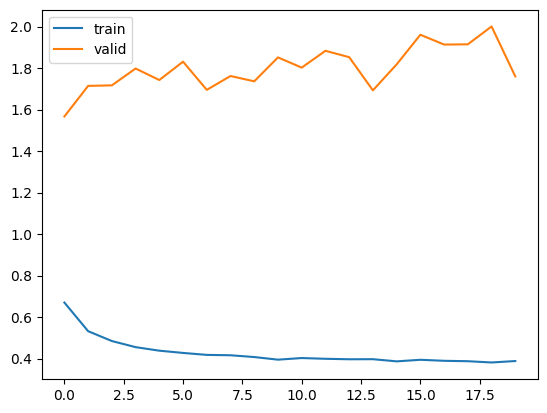

In [78]:
plt.plot(train_losses, label="train")
plt.plot(valid_losses, label="valid")
plt.legend()

In [29]:
tmp_path = pathlib.Path("models")
name = "uzasan_model_fizicki_inf.pth"

model = PINN(len(input_col_names), len(target_col_names)).to(device)

model = torch.load(tmp_path / name, weights_only=False)
model = model.to(device)
model.eval()

PINN(
  (fc1): Linear(in_features=4, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=3, bias=True)
  (tanh): Tanh()
)

In [2]:
# Učitaj originalne nenormalizovane podatke za vizuelizaciju
file_name = "data"
data_path = pathlib.Path("data")

train_df_original = pd.read_csv(data_path / f"{file_name}_train.csv")
test_df_original = pd.read_csv(data_path / f"{file_name}_test.csv")

print(f"Train skup: {train_df_original.shape[0]} redova")
print(f"Test skup: {test_df_original.shape[0]} redova")
print(f"\nVremenske korake: {sorted(train_df_original['time'].unique())}")
print(f"Reynolds brojevi: {sorted(train_df_original['re'].unique())}")

Train skup: 344064 redova
Test skup: 98304 redova

Vremenske korake: [np.float64(0.0), np.float64(0.2), np.float64(0.4)]
Reynolds brojevi: [np.float64(136.73469387755102), np.float64(191.8367346938776), np.float64(228.57142857142856), np.float64(265.30612244897964), np.float64(283.6734693877551), np.float64(302.0408163265306), np.float64(357.1428571428572), np.float64(393.8775510204082), np.float64(430.6122448979592), np.float64(467.34693877551024), np.float64(485.7142857142858), np.float64(504.08163265306126), np.float64(522.4489795918367), np.float64(540.8163265306123), np.float64(595.9183673469388), np.float64(614.2857142857143), np.float64(632.6530612244899), np.float64(669.3877551020408), np.float64(706.1224489795919), np.float64(724.4897959183675), np.float64(742.8571428571429), np.float64(761.2244897959184), np.float64(797.9591836734694), np.float64(834.6938775510205), np.float64(871.4285714285716), np.float64(889.795918367347), np.float64(908.1632653061224), np.float64(1000.0)]

Dostupni Reynolds brojevi: [np.float64(136.73469387755102), np.float64(191.8367346938776), np.float64(228.57142857142856), np.float64(265.30612244897964), np.float64(283.6734693877551)]... (ukupno 28)
Dostupni vremenske korake: [np.float64(0.0), np.float64(0.2), np.float64(0.4)]


/home/milos-pavlovic/env/lib/python3.13/site-packages/matplotlib/quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/home/milos-pavlovic/env/lib/python3.13/site-packages/matplotlib/quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


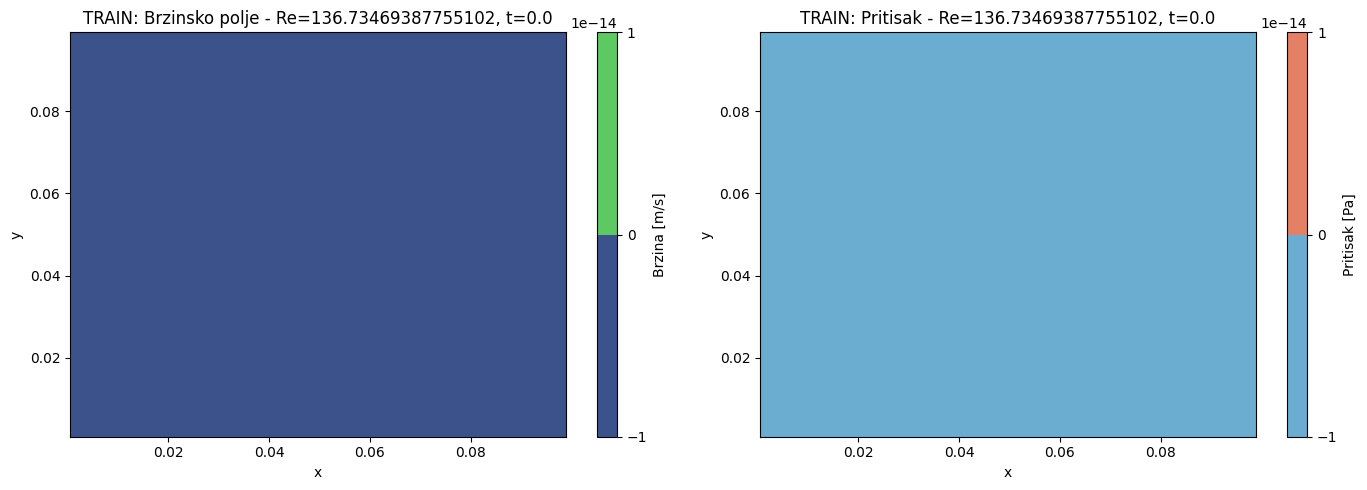

In [5]:
# Vizuelizacija za određeni vremenski trenutak i Reynolds broj
def plot_velocity_and_pressure(df, time_step, re_value, title_prefix=""):
    """Vizuelizuje brzinsko polje i pritisak"""
    data = df[(df['time'] == time_step) & (df['re'] == re_value)].copy()
    
    if len(data) == 0:
        print(f"Nema podataka za time={time_step}, Re={re_value}")
        return
    
    # Kreiraj grid
    x_unique = sorted(data['x'].unique())
    y_unique = sorted(data['y'].unique())
    
    nx, ny = len(x_unique), len(y_unique)
    
    X = data['x'].values.reshape(ny, nx)
    Y = data['y'].values.reshape(ny, nx)
    U_x = data['U_x'].values.reshape(ny, nx)
    U_y = data['U_y'].values.reshape(ny, nx)
    P = data['p'].values.reshape(ny, nx)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Brzinsko polje
    ax = axes[0]
    speed = np.sqrt(U_x**2 + U_y**2)
    cf = ax.contourf(X, Y, speed, levels=20, cmap='viridis')
    ax.quiver(X[::2, ::2], Y[::2, ::2], U_x[::2, ::2], U_y[::2, ::2], alpha=0.6)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title_prefix} Brzinsko polje - Re={re_value}, t={time_step}')
    plt.colorbar(cf, ax=ax, label='Brzina [m/s]')
    
    # Pritisak
    ax = axes[1]
    cf = ax.contourf(X, Y, P, levels=20, cmap='RdBu_r')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title_prefix} Pritisak - Re={re_value}, t={time_step}')
    plt.colorbar(cf, ax=ax, label='Pritisak [Pa]')
    
    plt.tight_layout()
    plt.show()

# Primjer: vizuelizacija train skupa
re_values = sorted(train_df_original['re'].unique())
time_steps = sorted(train_df_original['time'].unique())

print(f"Dostupni Reynolds brojevi: {re_values[:5]}... (ukupno {len(re_values)})")
print(f"Dostupni vremenske korake: {time_steps}")

# Vizuelizuj prvi Reynolds broj na prvom vremenskom koraku
plot_velocity_and_pressure(train_df_original, time_steps[0], re_values[0], "TRAIN:")

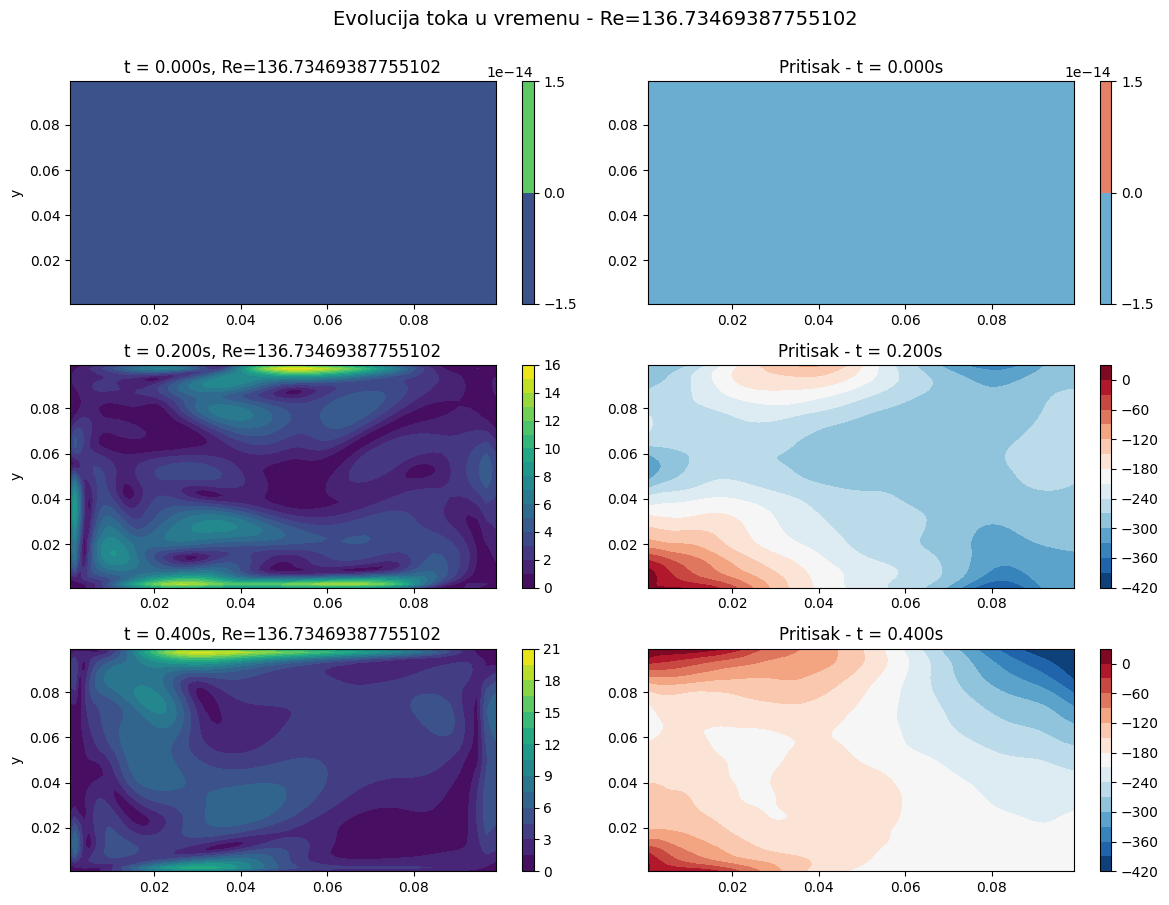

In [8]:
# Vizuelizacija evolucije kroz vrijeme za fiksni Reynolds broj
def plot_evolution_in_time(df, re_value, num_plots):
    """Prikaži kako se brzina i pritisak mijenjaju tijekom vremena"""
    data_re = df[df['re'] == re_value]
    time_steps = sorted(data_re['time'].unique())
    
    # Odaberi ravnomjerno raspoređene vremenske korake
    step_size = max(1, len(time_steps) // num_plots)
    selected_times = time_steps[::step_size][:num_plots]
    
    fig, axes = plt.subplots(num_plots, 2, figsize=(12, 3*num_plots))
    if num_plots == 1:
        axes = [axes]
    
    for idx, t in enumerate(selected_times):
        data = data_re[data_re['time'] == t]
        
        x_unique = sorted(data['x'].unique())
        y_unique = sorted(data['y'].unique())
        nx, ny = len(x_unique), len(y_unique)
        
        X = data['x'].values.reshape(ny, nx)
        Y = data['y'].values.reshape(ny, nx)
        U_x = data['U_x'].values.reshape(ny, nx)
        U_y = data['U_y'].values.reshape(ny, nx)
        P = data['p'].values.reshape(ny, nx)
        
        # Brzina
        speed = np.sqrt(U_x**2 + U_y**2)
        cf = axes[idx][0].contourf(X, Y, speed, levels=15, cmap='viridis')
        axes[idx][0].set_title(f't = {t:.3f}s, Re={re_value}')
        axes[idx][0].set_ylabel('y')
        plt.colorbar(cf, ax=axes[idx][0])
        
        # Pritisak
        cf = axes[idx][1].contourf(X, Y, P, levels=15, cmap='RdBu_r')
        axes[idx][1].set_title(f'Pritisak - t = {t:.3f}s')
        plt.colorbar(cf, ax=axes[idx][1])
    
    fig.suptitle(f'Evolucija toka u vremenu - Re={re_value}', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

# Vizuelizuj evoluciju za najmanji Reynolds broj
tmp = train_df_original['time'].unique()


plot_evolution_in_time(train_df_original, re_values[0], num_plots=len(tmp))

MAE U_x: 0.099913
MAE U_y: 0.052762
MAE p: 5.884275


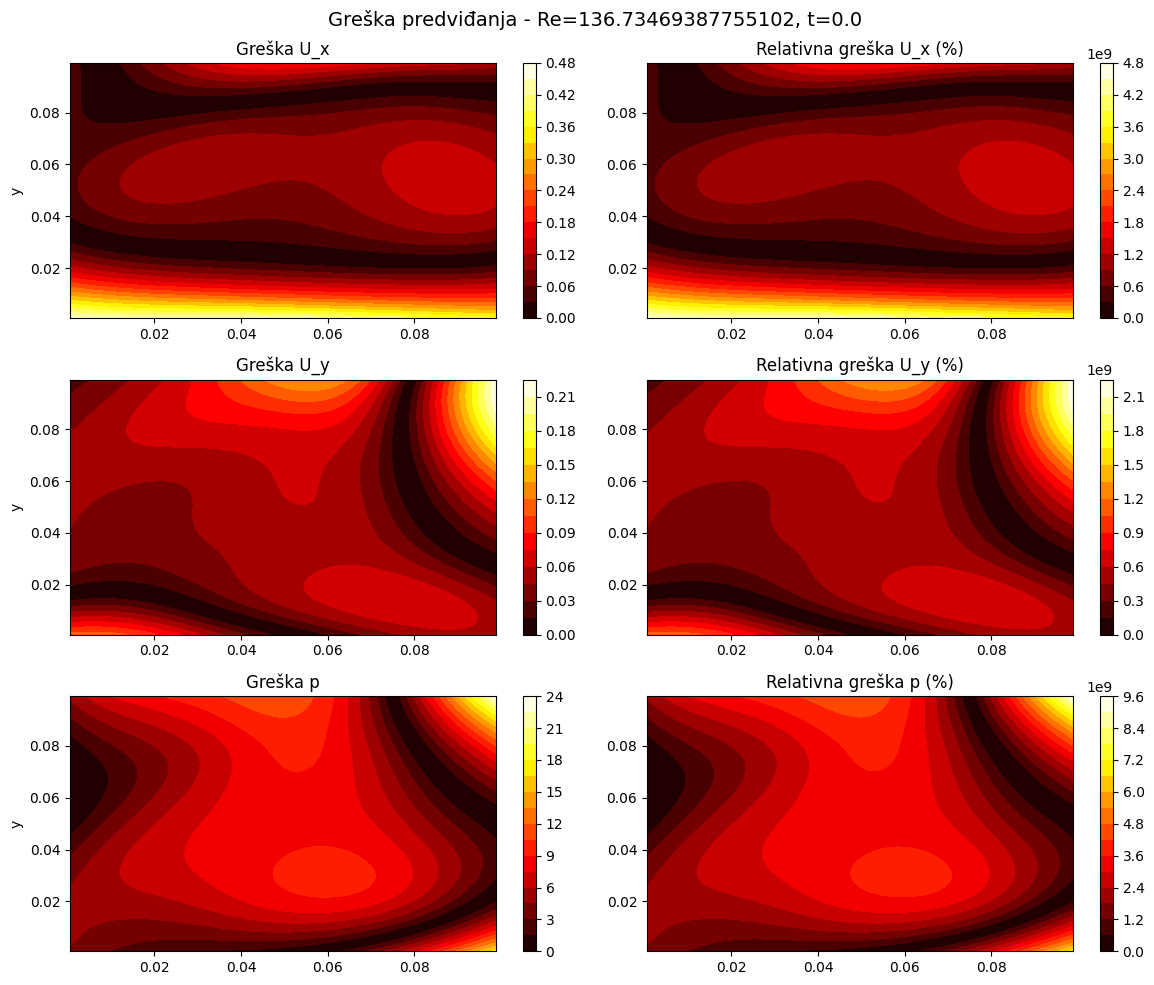

In [40]:
# Poređenje predviđanja modela sa stvarnim podacima
def compare_predictions(model, df, time_step, re_value, mean, std, device):
    """Vizuelizuje razliku između predviđanja modela i stvarnih podataka"""
    data = df[(df['time'] == time_step) & (df['re'] == re_value)].copy()
    
    if len(data) == 0:
        print(f"Nema podataka za time={time_step}, Re={re_value}")
        return
    
    # Pripremi ulazne podatke (nenormalizovane)
    input_data = data[['time', 're', 'x', 'y']].values
    target_data = data[['U_x', 'U_y', 'p']].values
    
    # Normalizuj kao što je rađeno u treningu
    input_norm = (input_data - mean[['time', 're', 'x', 'y']].values) / std[['time', 're', 'x', 'y']].values
    target_norm = (target_data - mean[['U_x', 'U_y', 'p']].values) / std[['U_x', 'U_y', 'p']].values
    
    # Pretvori u tensore
    input_tensor = torch.tensor(input_norm, dtype=torch.float32).to(device)
    target_tensor = torch.tensor(target_norm, dtype=torch.float32).to(device)
    
    # Predviđanje
    model.eval()
    with torch.no_grad():
        pred = model(input_tensor).cpu().numpy()
    target = target_tensor.cpu().numpy()
    
    # Denormalizuj za prikaz
    pred_denorm = pred * std[['U_x', 'U_y', 'p']].values + mean[['U_x', 'U_y', 'p']].values
    target_denorm = target * std[['U_x', 'U_y', 'p']].values + mean[['U_x', 'U_y', 'p']].values
    
    # Kreiraj grid
    x_unique = sorted(data['x'].unique())
    y_unique = sorted(data['y'].unique())
    nx, ny = len(x_unique), len(y_unique)
    
    X = data['x'].values.reshape(ny, nx)
    Y = data['y'].values.reshape(ny, nx)
    
    U_x_true = target_denorm[:, 0].reshape(ny, nx)
    U_y_true = target_denorm[:, 1].reshape(ny, nx)
    P_true = target_denorm[:, 2].reshape(ny, nx)
    
    U_x_pred = pred_denorm[:, 0].reshape(ny, nx)
    U_y_pred = pred_denorm[:, 1].reshape(ny, nx)
    P_pred = pred_denorm[:, 2].reshape(ny, nx)
    
    # Greške
    error_u_x = np.abs(U_x_true - U_x_pred)
    error_u_y = np.abs(U_y_true - U_y_pred)
    error_p = np.abs(P_true - P_pred)
    
    print(f"MAE U_x: {error_u_x.mean():.6f}")
    print(f"MAE U_y: {error_u_y.mean():.6f}")
    print(f"MAE p: {error_p.mean():.6f}")
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    
    # Apsolutne greške
    for idx, (error, label) in enumerate([(error_u_x, 'U_x'), (error_u_y, 'U_y'), (error_p, 'p')]):
        cf = axes[idx, 0].contourf(X, Y, error, levels=15, cmap='hot')
        axes[idx, 0].set_title(f'Greška {label}')
        axes[idx, 0].set_ylabel('y')
        plt.colorbar(cf, ax=axes[idx, 0])
        
        # Relativna greška (%)
        if label == 'p':
            rel_error = 100 * error / (np.abs(P_true) + 1e-8)
        else:
            true_val = U_x_true if label == 'U_x' else U_y_true
            rel_error = 100 * error / (np.abs(true_val) + 1e-8)
        
        cf = axes[idx, 1].contourf(X, Y, rel_error, levels=15, cmap='hot')
        axes[idx, 1].set_title(f'Relativna greška {label} (%)')
        plt.colorbar(cf, ax=axes[idx, 1])
    
    plt.suptitle(f'Greška predviđanja - Re={re_value}, t={time_step}', fontsize=14)
    plt.tight_layout()
    plt.show()

mean = train_df.mean()
std = train_df.std()
compare_predictions(model, train_df_original, time_steps[0], re_values[0], mean, std, device)

MAE U_x: 0.032696
MAE U_y: 0.028243
MAE p: 0.542688


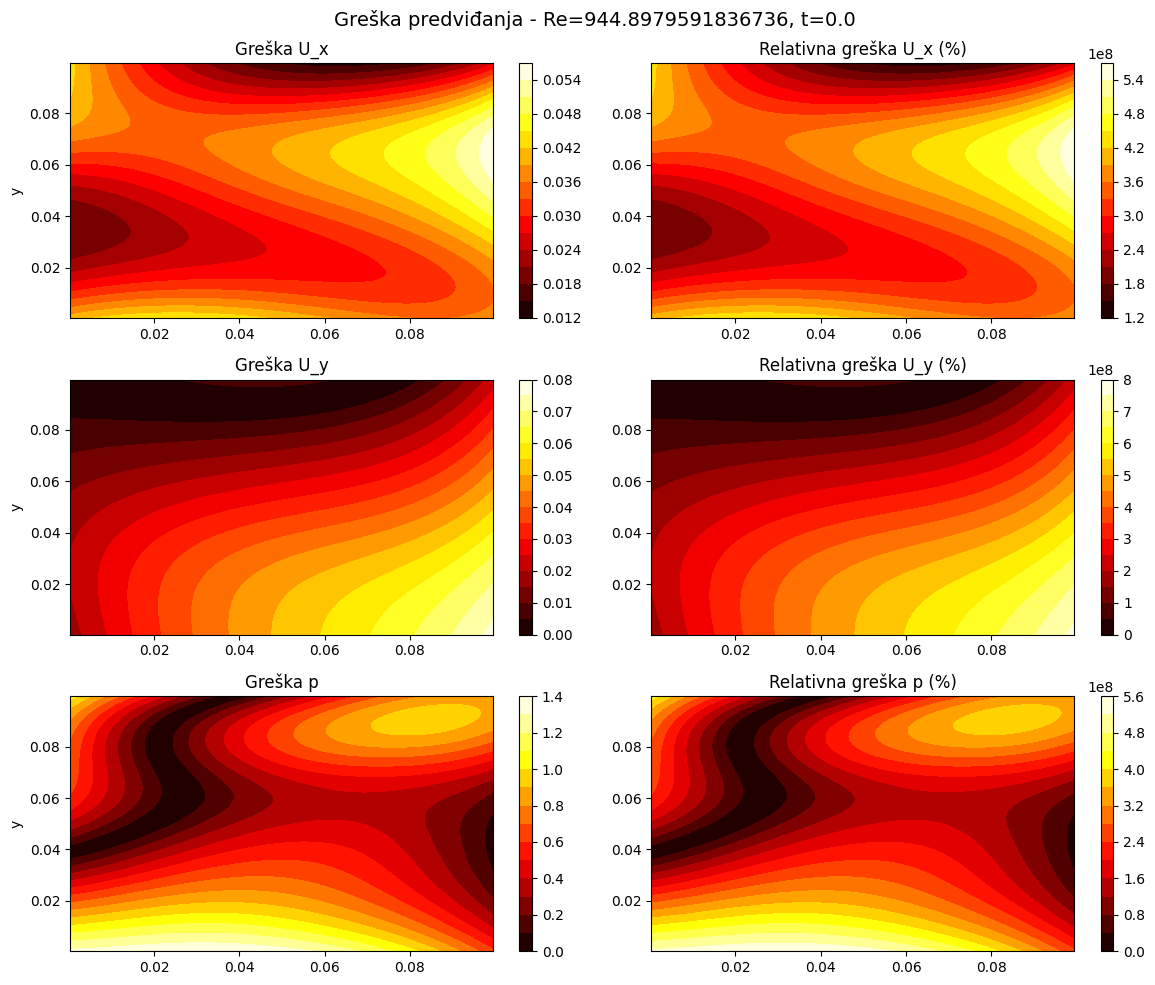

MAE U_x: 0.034514
MAE U_y: 0.028851
MAE p: 0.543416


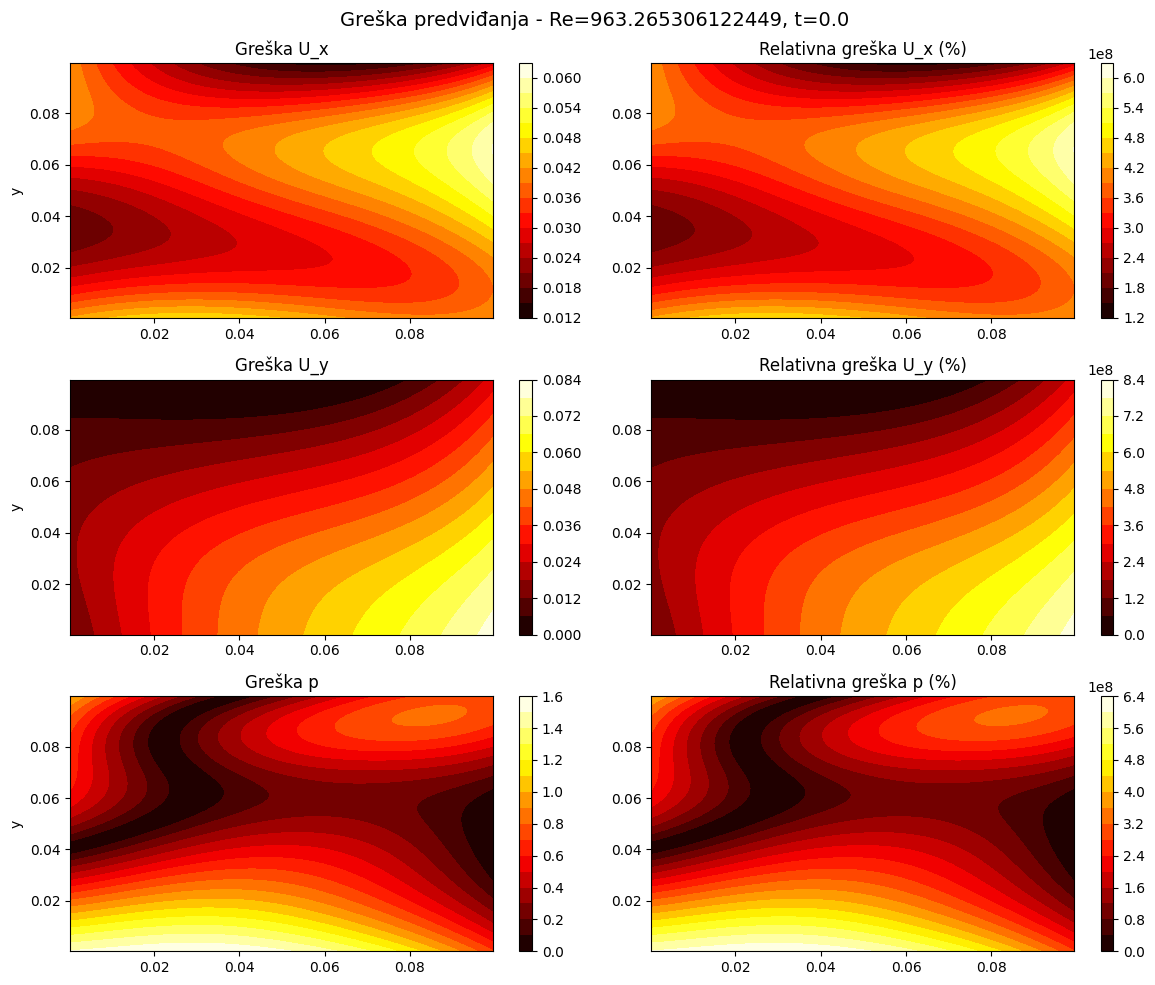

In [42]:
# Analiza greške na test setu
def evaluate_on_test_set(model, test_df_orig, mean, std, device, num_samples=5):
    """Proceni grešku modela na test setu"""
    test_errors = []
    
    # Uzmi slučajne uzorke za vizuelizaciju
    re_values = sorted(test_df_orig['re'].unique())
    time_steps = sorted(test_df_orig['time'].unique())
    
    selected_re = np.random.choice(re_values, min(num_samples, len(re_values)), replace=False)
    
    for re_val in selected_re:
        data_orig = test_df_orig[test_df_orig['re'] == re_val]
        times_for_re = sorted(data_orig['time'].unique())
        
        if len(times_for_re) > 0:
            t = times_for_re[0]  # Prvi vremenski korak
            
            try:
                compare_predictions(model, test_df_orig, t, re_val, mean, std, device)
            except Exception as e:
                print(f"Greška pri vizuelizaciji Re={re_val}: {e}")

evaluate_on_test_set(model, test_df_original, mean, std, device, num_samples=5)


In [54]:
# Animacija toka kroz vrijeme - generiši slike pa složi u GIF
def animate_flow(df, re_value, output_file="flow_animation.gif", fps=3):
    """
    Kreira animaciju brzinskog polja i pritiska kroz vrijeme:
    1. Generiše sve frame-ove kao slike
    2. Kombinuje ih u GIF
    
    Args:
        df: DataFrame sa podacima
        re_value: Reynolds broj
        output_file: Putanja GIF fajla (npr. 'animation.gif')
        fps: Broj frejmova po sekundi
    """
    from PIL import Image
    import tempfile
    import os
    
    data_re = df[df['re'] == re_value]
    time_steps = sorted(data_re['time'].unique())
    
    if len(time_steps) < 2:
        print(f"Nema dovoljno vremenskih koraka za Re={re_value}")
        return
    
    # Kreiraj grid za prvi vremenski korak
    data_first = data_re[data_re['time'] == time_steps[0]]
    x_unique = sorted(data_first['x'].unique())
    y_unique = sorted(data_first['y'].unique())
    nx, ny = len(x_unique), len(y_unique)
    
    # Pripremi sve podatke unaprijed
    all_frames = []
    for t in time_steps:
        data = data_re[data_re['time'] == t]
        
        X = data['x'].values.reshape(ny, nx)
        Y = data['y'].values.reshape(ny, nx)
        U_x = data['U_x'].values.reshape(ny, nx)
        U_y = data['U_y'].values.reshape(ny, nx)
        P = data['p'].values.reshape(ny, nx)
        
        all_frames.append({
            'X': X, 'Y': Y, 'U_x': U_x, 'U_y': U_y, 'P': P, 'time': t
        })
    
    # Minmax za normalizaciju boja
    speed_all = [np.sqrt(f['U_x']**2 + f['U_y']**2) for f in all_frames]
    p_all = [f['P'] for f in all_frames]
    
    vmin_speed, vmax_speed = min([s.min() for s in speed_all]), max([s.max() for s in speed_all])
    vmin_p, vmax_p = min([p.min() for p in p_all]), max([p.max() for p in p_all])
    
    # Kreiraj privremeni direktorijum za slike
    with tempfile.TemporaryDirectory() as tmp_dir:
        frame_files = []
        
        # Generiši sve slike
        print(f"Generiši {len(all_frames)} frame-ova...")
        for idx, frame in enumerate(all_frames):
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            X, Y = frame['X'], frame['Y']
            U_x, U_y = frame['U_x'], frame['U_y']
            P = frame['P']
            speed = np.sqrt(U_x**2 + U_y**2)
            
            # Brzina (lijevo)
            cf0 = axes[0].contourf(X, Y, speed, levels=20, cmap='viridis', vmin=vmin_speed, vmax=vmax_speed)
            axes[0].quiver(X[::2, ::2], Y[::2, ::2], U_x[::2, ::2], U_y[::2, ::2], alpha=0.6)
            axes[0].set_xlabel('x')
            axes[0].set_ylabel('y')
            axes[0].set_title(f'Brzinsko polje - t = {frame["time"]:.3f}s')
            plt.colorbar(cf0, ax=axes[0], label='Brzina [m/s]')
            
            # Pritisak (desno)
            cf1 = axes[1].contourf(X, Y, P, levels=20, cmap='RdBu_r', vmin=vmin_p, vmax=vmax_p)
            axes[1].set_xlabel('x')
            axes[1].set_ylabel('y')
            axes[1].set_title(f'Pritisak - t = {frame["time"]:.3f}s')
            plt.colorbar(cf1, ax=axes[1], label='Pritisak [Pa]')
            
            fig.suptitle(f'Animacija toka - Re={re_value} (frejm {idx+1}/{len(all_frames)})', fontsize=14)
            plt.tight_layout()
            
            # Spremi kao sliku
            frame_path = os.path.join(tmp_dir, f'frame_{idx:04d}.png')
            fig.savefig(frame_path, dpi=100, bbox_inches='tight')
            frame_files.append(frame_path)
            
            plt.close(fig)
            
            # Progress
            if (idx + 1) % max(1, len(all_frames) // 5) == 0:
                print(f"  ✓ {idx+1}/{len(all_frames)} frame-ova generirano")
        
        # Kombinuj slike u GIF
        print(f"\nKombinujem slike u GIF ({output_file})...")
        images = [Image.open(f) for f in frame_files]
        
        duration = int(1000 / fps)  # Vrijeme po frame-u u ms
        images[0].save(
            output_file,
            save_all=True,
            append_images=images[1:],
            duration=duration,
            loop=0,
            optimize=False
        )
        
        print(f"✓ GIF spreman: {output_file}")
        print(f"  • Frejmova: {len(all_frames)}")
        print(f"  • Brzina: {fps} fps")
        print(f"  • Trajanje: {len(all_frames) / fps:.1f}s")
        
        return output_file

# Kreiraj GIF
output_path = animate_flow(train_df_original, re_values[0], output_file="flow_animation.gif", fps=3)

Generiši 3 frame-ova...
  ✓ 1/3 frame-ova generirano
  ✓ 2/3 frame-ova generirano
  ✓ 3/3 frame-ova generirano

Kombinujem slike u GIF (flow_animation.gif)...
✓ GIF spreman: flow_animation.gif
  • Frejmova: 3
  • Brzina: 3 fps
  • Trajanje: 1.0s


In [ ]:
# Primjer: Pokreni animaciju
# anim = animate_flow(train_df_original, re_values[0], fps=2)
# HTML(anim.to_jshtml())  # Prikazuje animaciju u notebooku

# Ili sačuvaj kao video datoteku:
# animate_flow(train_df_original, re_values[0], output_file='animation.mp4', fps=2)

In [ ]:
# Interaktivna vizuelizacija sa slajderom kroz vrijeme
def interactive_time_slider(df, re_value):
    """
    Kreira interaktivni slider za navigaciju kroz vremenske korake
    """

In [ ]:
# Primjer: Interaktivni slider
# widget = interactive_time_slider(train_df_original, re_values[0])
# display(widget)

MovieWriter ffmpeg unavailable; using Pillow instead.


Greška pri čuvanju: unknown file extension: .mp4
Animacija greške je spremna!


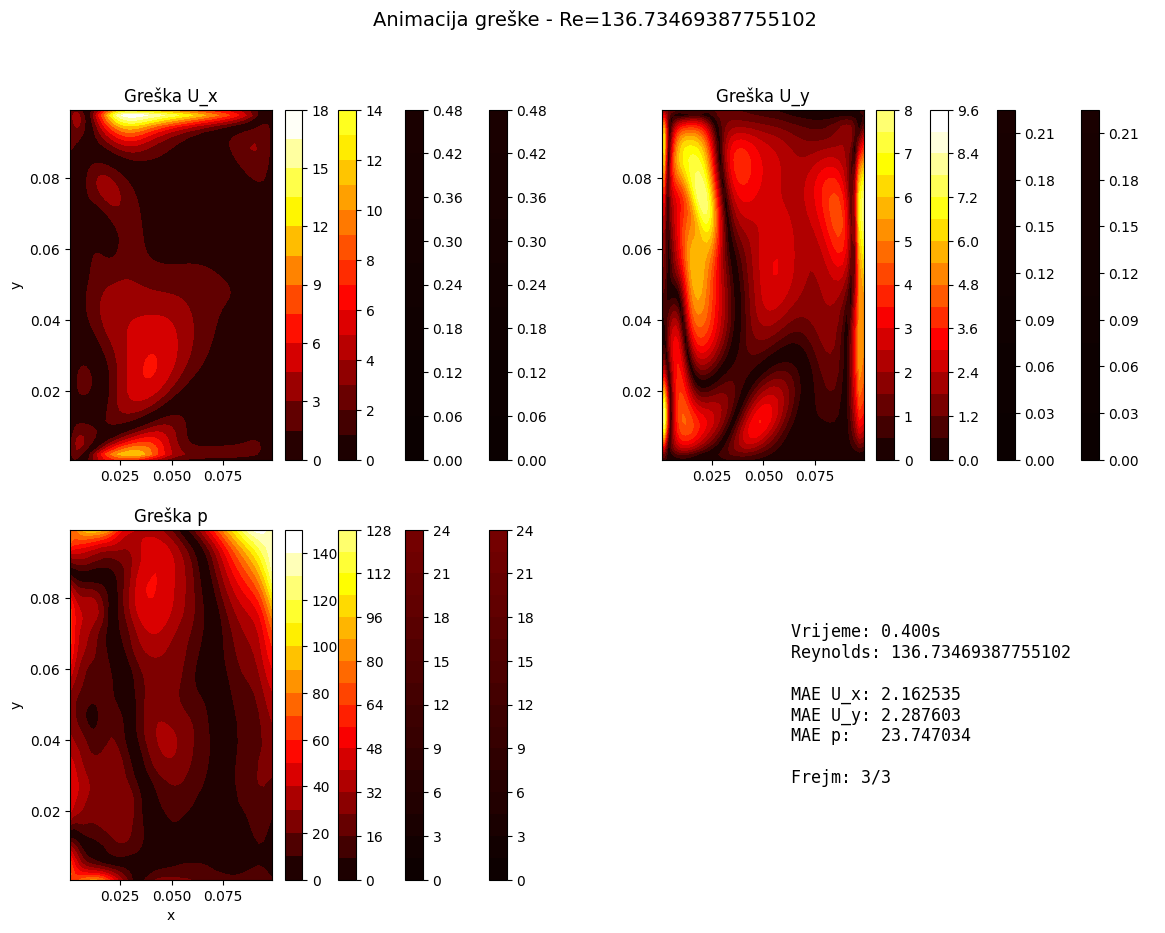

In [ ]:
# Animacija greške kroz vrijeme
def animate_error(model, df_orig, re_value, mean, std, device, fps=2, output_file=None):
    """
    Animira grešku modela kroz vrijeme
    """
    data_re = df_orig[df_orig['re'] == re_value]
    time_steps = sorted(data_re['time'].unique())
    
    if len(time_steps) < 2:
        print(f"Nema dovoljno vremenskih koraka za Re={re_value}")
        return
    
    # Kreiraj grid za prvi vremenski korak
    data_first = data_re[data_re['time'] == time_steps[0]]
    x_unique = sorted(data_first['x'].unique())
    y_unique = sorted(data_first['y'].unique())
    nx, ny = len(x_unique), len(y_unique)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Pripremi sve podatke unaprijed
    all_errors = []
    for t in time_steps:
        data = data_re[data_re['time'] == t]
        
        # Pripremi ulaze
        input_data = data[['time', 're', 'x', 'y']].values
        target_data = data[['U_x', 'U_y', 'p']].values
        
        # Normalizuj
        input_norm = (input_data - mean[['time', 're', 'x', 'y']].values) / std[['time', 're', 'x', 'y']].values
        target_norm = (target_data - mean[['U_x', 'U_y', 'p']].values) / std[['U_x', 'U_y', 'p']].values
        
        # Predviđanje
        input_tensor = torch.tensor(input_norm, dtype=torch.float32).to(device)
        model.eval()
        with torch.no_grad():
            pred_norm = model(input_tensor).cpu().numpy()
        
        # Denormalizuj
        pred = pred_norm * std[['U_x', 'U_y', 'p']].values + mean[['U_x', 'U_y', 'p']].values
        target = target_norm * std[['U_x', 'U_y', 'p']].values + mean[['U_x', 'U_y', 'p']].values
        
        # Greške
        X = data['x'].values.reshape(ny, nx)
        Y = data['y'].values.reshape(ny, nx)
        
        error_u_x = np.abs(target[:, 0] - pred[:, 0]).reshape(ny, nx)
        error_u_y = np.abs(target[:, 1] - pred[:, 1]).reshape(ny, nx)
        error_p = np.abs(target[:, 2] - pred[:, 2]).reshape(ny, nx)
        
        all_errors.append({
            'X': X, 'Y': Y, 
            'error_u_x': error_u_x, 'error_u_y': error_u_y, 'error_p': error_p,
            'time': t
        })
    
    # Minmax
    err_ux_all = [e['error_u_x'] for e in all_errors]
    err_uy_all = [e['error_u_y'] for e in all_errors]
    err_p_all = [e['error_p'] for e in all_errors]
    
    vmin_ux, vmax_ux = min([e.min() for e in err_ux_all]), max([e.max() for e in err_ux_all])
    vmin_uy, vmax_uy = min([e.min() for e in err_uy_all]), max([e.max() for e in err_uy_all])
    vmin_p, vmax_p = min([e.min() for e in err_p_all]), max([e.max() for e in err_p_all])
    
    # Kreiraj privremeni direktorijum za slike
    from PIL import Image
    import tempfile
    import os
    
    with tempfile.TemporaryDirectory() as tmp_dir:
        frame_files = []
        
        # Generiši sve slike
        print(f"Generiši {len(all_errors)} frame-ova greške...")
        for idx, frame in enumerate(all_errors):
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            
            X, Y = frame['X'], frame['Y']
            
            # U_x
            cf0 = axes[0, 0].contourf(X, Y, frame['error_u_x'], levels=15, cmap='hot', vmin=vmin_ux, vmax=vmax_ux)
            axes[0, 0].set_title(f'Greška U_x')
            axes[0, 0].set_ylabel('y')
            plt.colorbar(cf0, ax=axes[0, 0])
            
            # U_y
            cf1 = axes[0, 1].contourf(X, Y, frame['error_u_y'], levels=15, cmap='hot', vmin=vmin_uy, vmax=vmax_uy)
            axes[0, 1].set_title(f'Greška U_y')
            plt.colorbar(cf1, ax=axes[0, 1])
            
            # p
            cf2 = axes[1, 0].contourf(X, Y, frame['error_p'], levels=15, cmap='hot', vmin=vmin_p, vmax=vmax_p)
            axes[1, 0].set_title(f'Greška p')
            axes[1, 0].set_xlabel('x')
            axes[1, 0].set_ylabel('y')
            plt.colorbar(cf2, ax=axes[1, 0])
            
            # Statistika
            axes[1, 1].axis('off')
            stats_text = f"""
Vrijeme: {frame['time']:.3f}s
Reynolds: {re_value}

MAE U_x: {frame['error_u_x'].mean():.6f}
MAE U_y: {frame['error_u_y'].mean():.6f}
MAE p:   {frame['error_p'].mean():.6f}

Frejm: {idx+1}/{len(all_errors)}
            """
            axes[1, 1].text(0.1, 0.5, stats_text, fontsize=12, family='monospace',
                           verticalalignment='center')
            
            fig.suptitle(f'Animacija greške - Re={re_value}', fontsize=14)
            plt.tight_layout()
            
            # Spremi kao sliku
            frame_path = os.path.join(tmp_dir, f'frame_error_{idx:04d}.png')
            fig.savefig(frame_path, dpi=100, bbox_inches='tight')
            frame_files.append(frame_path)
            
            plt.close(fig)
            
            # Progress
            if (idx + 1) % max(1, len(all_errors) // 5) == 0:
                print(f"  ✓ {idx+1}/{len(all_errors)} frame-ova generirano")
        
        # Kombinuj slike u GIF ako je output_file specificiran
        if output_file:
            print(f"\nKombinujem slike u GIF ({output_file})...")
            images = [Image.open(f) for f in frame_files]
            
            duration = int(1000 / fps)  # Vrijeme po frame-u u ms
            images[0].save(
                output_file,
                save_all=True,
                append_images=images[1:],
                duration=duration,
                loop=0,
                optimize=False
            )
            
            print(f"✓ GIF greške spreman: {output_file}")
            print(f"  • Frejmova: {len(all_errors)}")
            print(f"  • Brzina: {fps} fps")
            print(f"  • Trajanje: {len(all_errors) / fps:.1f}s")
            
            return output_file
        else:
            print(f"✓ Slike generirane - {len(all_errors)} frame-ova")

animate_error(model, train_df_original, re_values[0], mean, std, device, fps=2, output_file="error_animation.gif")

print("Animacija greške je spremna!")

In [ ]:
# PRIMJERI KORIŠTENJA
# ==================

# 1. ANIMACIJA - Gledaj tijek kako se razvija u vremenu
# -------------------------------------------------------
# anim = animate_flow(train_df_original, re_values[0], fps=3)
# HTML(anim.to_jshtml())  # Prikazuje animaciju u notebooku

# Ili sačuvaj kao MP4:
# animate_flow(train_df_original, re_values[0], output_file='tijek.mp4', fps=3)


# 2. INTERAKTIVNI SLIDER - Ručno navigiraj kroz vrijeme
# -------------------------------------------------------
# widget = interactive_time_slider(train_df_original, re_values[0])
# display(widget)


# 3. ANIMACIJA GREŠKE - Vidi kako model greši kroz vrijeme
# -------------------------------------------------------
# NAKON TRENINGA MODELA:
# anim_error = animate_error(model, test_df_original, re_values[0], mean, std, device, fps=2)
# HTML(anim_error.to_jshtml())